# Major Data Analytics Project

## Domain: Agriculture

### Project Theme: Seasonal Agriculture Performance

### Tools:
Python, Pandas, NumPy, Matplotlib, Seaborn

### Project Goal:
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.



# 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

Students should independently explore the dataset, formulate relevant analytical questions, select suitable analytical techniques and communicate findings based on evidence from the data.

# 2. Project Objectives

- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the data for analysis.
- Examine how agricultural performance varies across seasons.
- Identify important seasonal patterns and trends.
- Investigate relationships between seasonal conditions and agricultural outcomes.
- Compare relevant groups within different seasons.
- Identify significant differences or unusual patterns.
- Apply appropriate statistical and visualization techniques.
- Interpret findings based on evidence from the dataset.
- Develop meaningful conclusions and data-driven recommendations.

# 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

Dataset file:

seasonal_agriculture_performance_dataset.csv

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [ ]:
# Load the dataset

file_path = "seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


# 4. Initial Data Understanding

The first step is to understand the structure, size, variables and basic characteristics of the dataset.

In [ ]:
# Dataset shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [ ]:
# Top 5 rows

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [ ]:
# Bottom 5 rows

df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [ ]:
# Random sample of records

df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [ ]:
# Column names

print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [ ]:
# Data types and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
print(df.head())
print(df.shape)
print(df.columns.tolist())

   Farm_ID           State  District    Crop  Season  Farm_Area_Hectares  \
0  SF10001  Andhra Pradesh    Rajkot   Wheat  Kharif                0.53   
1  SF10002     Maharashtra  Nalgonda   Maize  Kharif                6.53   
2  SF10003       Telangana  Warangal  Pulses    Rabi                4.86   
3  SF10004       Telangana    Indore    Rice  Kharif                4.50   
4  SF10005       Karnataka  Ludhiana   Maize    Zaid                4.21   

   Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  Soil_pH  \
0       486.40              24.30         69.10                5.80     7.14   
1       855.40              25.70         78.40                5.10     5.20   
2       455.60              23.90         56.40               10.30     5.82   
3       753.20              29.70         65.20                6.30     5.98   
4       101.60              34.10         55.20                6.50     6.90   

   Soil_Moisture_pct  Nitrogen_kg_ha  Phosphorus_kg_ha  Potass

In [ ]:
print(df.columns)

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')


In [ ]:
# Statistical summary of numerical columns

df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


# 5. Data Quality Analysis

Before performing analysis, investigate missing values, duplicates, data types and unusual values.

Student task:
Explain what you observe and justify each cleaning decision.

In [ ]:
# Missing values

missing = df.isnull().sum().sort_values(ascending=False)

missing_percentage = (
    (df.isnull().mean() * 100)
    .sort_values(ascending=False)
)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage.round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
]

missing_summary

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


In [ ]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# Remove duplicate records

df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after duplicate removal:", df.shape)

Dataset shape after duplicate removal: (4000, 28)


In [ ]:
# Check missing values after duplicate removal

df.isnull().sum().sort_values(ascending=False).head(10)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


In [ ]:
# Separate numerical and categorical columns

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [ ]:
# Fill missing numerical values using median

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values using mode

for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled.")

Missing values handled.


In [ ]:
# Check missing values after cleaning

missing_after = df.isnull().sum().sort_values(ascending=False)

missing_after.head(10)

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


# 6. Variable Understanding

The variables in the dataset can be grouped into:

- Identifier variables
- Categorical variables
- Numerical variables
- Environmental variables
- Operational variables
- Production/performance variables
- Economic variables

Student task:
Explain which variables are most relevant to the seasonal-performance problem and why.

In [ ]:
# Numerical and categorical columns

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

categorical_columns = df.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [ ]:
# Unique values of categorical columns

for col in categorical_columns:
    print("\n", col)
    print(df[col].unique())


 Farm_ID
['SF10001' 'SF10002' 'SF10003' ... 'SF13998' 'SF13999' 'SF14000']

 State
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

 District
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

 Crop
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

 Season
['Kharif' 'Rabi' 'Zaid']

 Irrigation_Method
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [ ]:
# Number of unique values

for col in categorical_columns:
    print(col, ":", df[col].nunique())

Farm_ID : 4000
State : 8
District : 10
Crop : 8
Season : 3
Irrigation_Method : 4


# 7. Seasonal Analysis

The main focus of this project is to investigate how agricultural performance varies across different seasons.

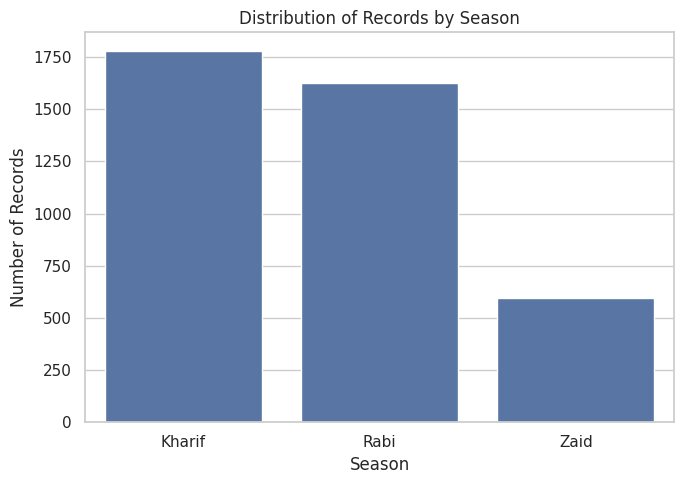

In [ ]:
# Distribution of records by Season

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Season")

plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

In [ ]:
# Number of records in each season

season_counts = df["Season"].value_counts()

print(season_counts)

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


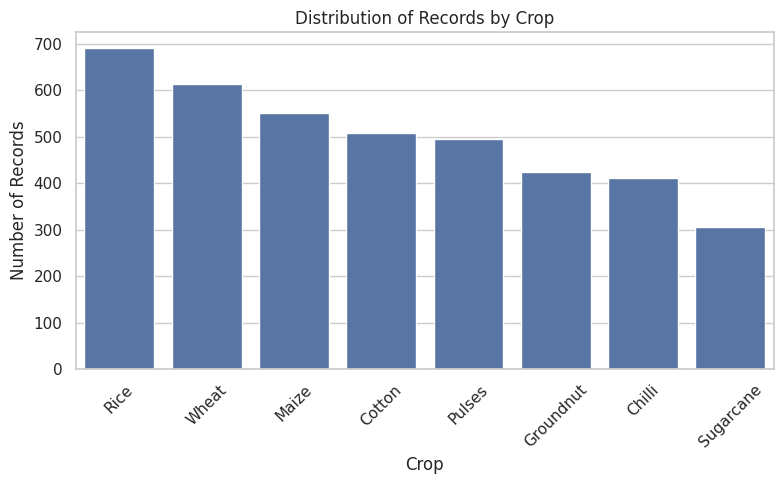

In [ ]:
# Distribution of crops

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Crop",
    order=df["Crop"].value_counts().index
)

plt.title("Distribution of Records by Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

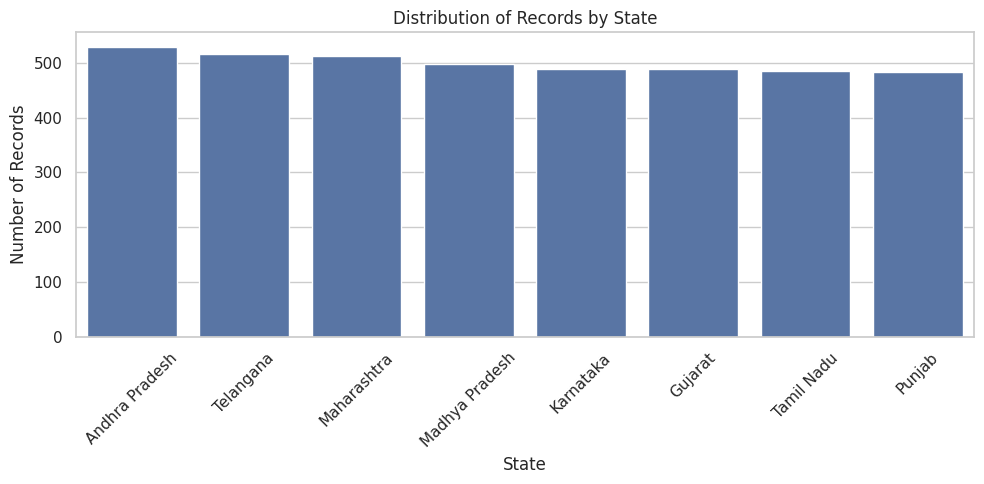

In [ ]:
# Distribution by state

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="State",
    order=df["State"].value_counts().index
)

plt.title("Distribution of Records by State")
plt.xlabel("State")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

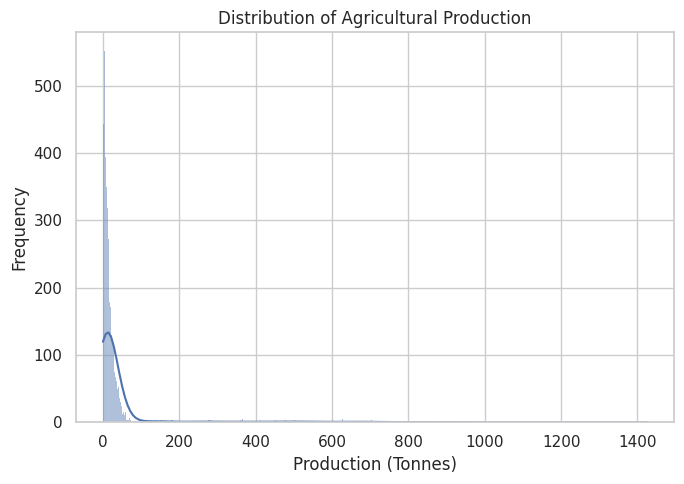

In [ ]:
# Production distribution

if "Production_Tonnes" in df.columns:

    plt.figure(figsize=(7, 5))

    sns.histplot(
        data=df,
        x="Production_Tonnes",
        kde=True
    )

    plt.title("Distribution of Agricultural Production")
    plt.xlabel("Production (Tonnes)")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

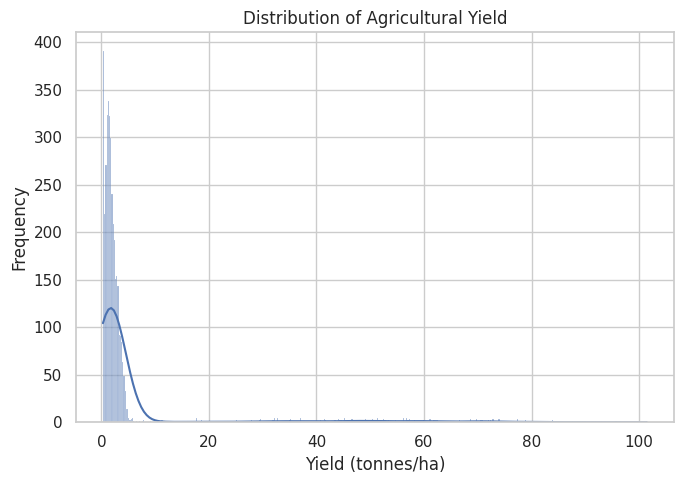

In [ ]:
# Yield Distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.histplot(
    data=df,
    x="Yield_Tonnes_Ha",
    kde=True
)

plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

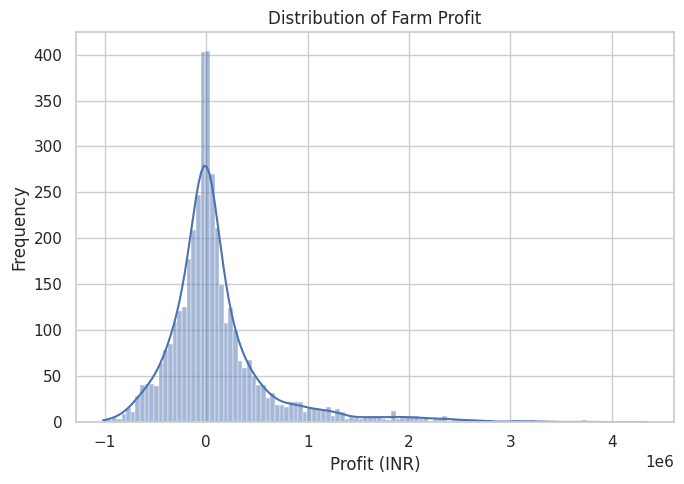

In [ ]:
# Profit distribution

if "Profit_INR" in df.columns:

    plt.figure(figsize=(7, 5))

    sns.histplot(
        data=df,
        x="Profit_INR",
        kde=True
    )

    plt.title("Distribution of Farm Profit")
    plt.xlabel("Profit (INR)")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# 8. Seasonal Performance Comparison

Compare important agricultural performance indicators across seasons.

Season
Kharif   46.31
Rabi     41.49
Zaid     38.89
Name: Production_Tonnes, dtype: float64


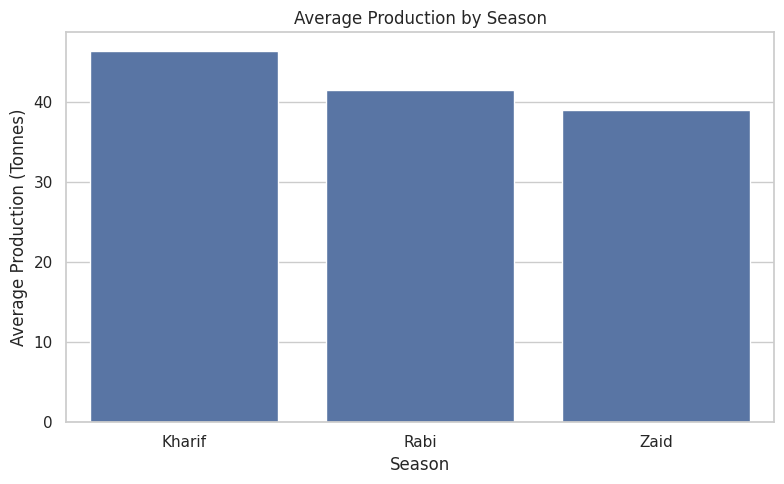

In [ ]:
# Average production by season

if "Production_Tonnes" in df.columns:

    seasonal_production = (
        df.groupby("Season")["Production_Tonnes"]
        .mean()
        .sort_values(ascending=False)
    )

    print(seasonal_production)

    plt.figure(figsize=(8, 5))

    sns.barplot(
        x=seasonal_production.index,
        y=seasonal_production.values
    )

    plt.title("Average Production by Season")
    plt.xlabel("Season")
    plt.ylabel("Average Production (Tonnes)")

    plt.tight_layout()
    plt.show()

Average Yield by Season:
Season
Kharif   5.63
Rabi     5.04
Zaid     4.64
Name: Yield_Tonnes_Ha, dtype: float64


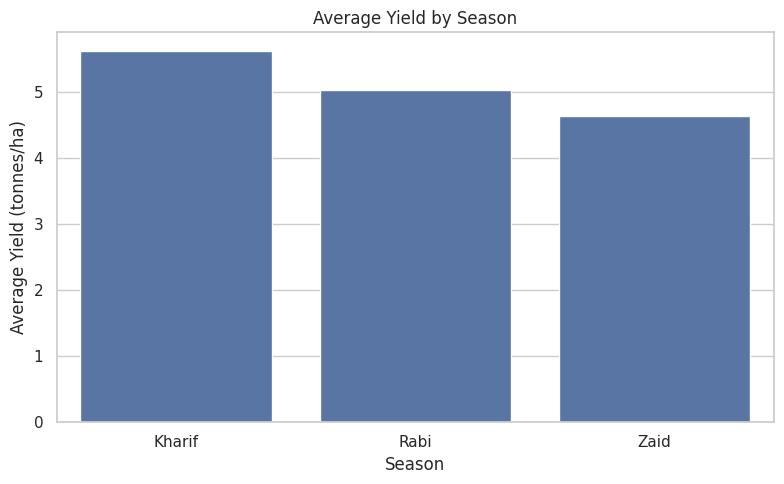

In [ ]:
# Average Yield by Season

import matplotlib.pyplot as plt
import seaborn as sns

seasonal_yield = (
    df.groupby("Season")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Yield by Season:")
print(seasonal_yield)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=seasonal_yield.index,
    y=seasonal_yield.values
)

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (tonnes/ha)")

plt.tight_layout()
plt.show()

Season
Kharif   178,914.65
Rabi      87,689.47
Zaid     -24,804.82
Name: Profit_INR, dtype: float64


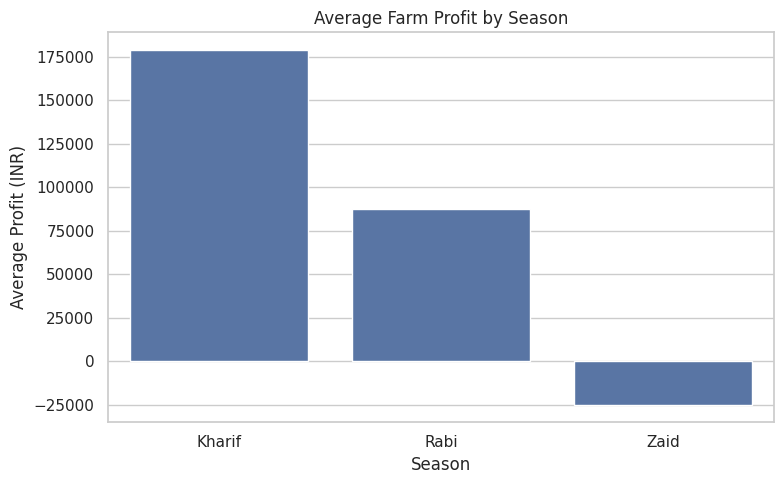

In [ ]:
# Average profit by season

if "Profit_INR" in df.columns:

    seasonal_profit = (
        df.groupby("Season")["Profit_INR"]
        .mean()
        .sort_values(ascending=False)
    )

    print(seasonal_profit)

    plt.figure(figsize=(8, 5))

    sns.barplot(
        x=seasonal_profit.index,
        y=seasonal_profit.values
    )

    plt.title("Average Farm Profit by Season")
    plt.xlabel("Season")
    plt.ylabel("Average Profit (INR)")

    plt.tight_layout()
    plt.show()

Season
Kharif   849.20
Rabi     437.62
Zaid     304.65
Name: Rainfall_mm, dtype: float64


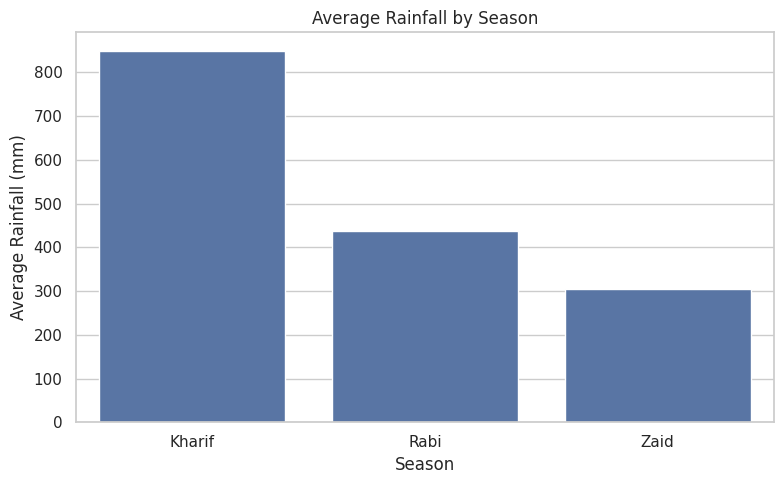

In [ ]:
# Average rainfall by season

if "Rainfall_mm" in df.columns:

    rainfall_season = (
        df.groupby("Season")["Rainfall_mm"]
        .mean()
        .sort_values(ascending=False)
    )

    print(rainfall_season)

    plt.figure(figsize=(8, 5))

    sns.barplot(
        x=rainfall_season.index,
        y=rainfall_season.values
    )

    plt.title("Average Rainfall by Season")
    plt.xlabel("Season")
    plt.ylabel("Average Rainfall (mm)")

    plt.tight_layout()
    plt.show()

Season
Zaid     31.04
Kharif   28.45
Rabi     23.49
Name: Avg_Temperature_C, dtype: float64


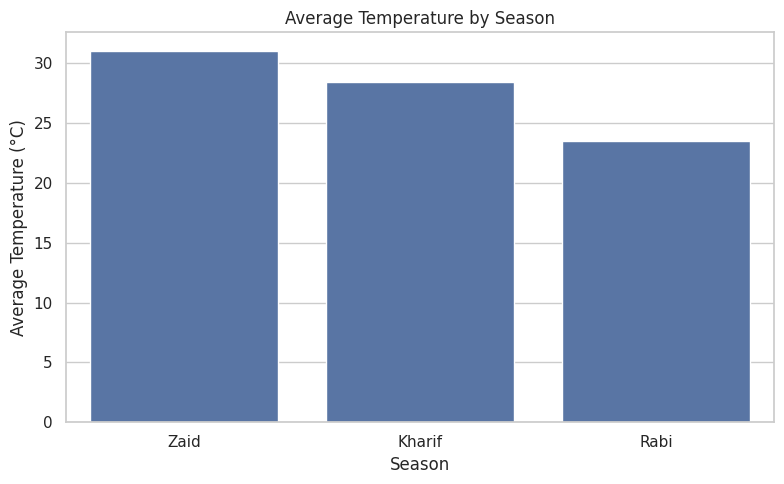

In [ ]:
# Average temperature by season

if "Avg_Temperature_C" in df.columns:

    temperature_season = (
        df.groupby("Season")["Avg_Temperature_C"]
        .mean()
        .sort_values(ascending=False)
    )

    print(temperature_season)

    plt.figure(figsize=(8, 5))

    sns.barplot(
        x=temperature_season.index,
        y=temperature_season.values
    )

    plt.title("Average Temperature by Season")
    plt.xlabel("Season")
    plt.ylabel("Average Temperature (°C)")

    plt.tight_layout()
    plt.show()

Season
Zaid     6,419.89
Kharif   6,102.20
Rabi     5,846.99
Name: Water_Used_m3, dtype: float64


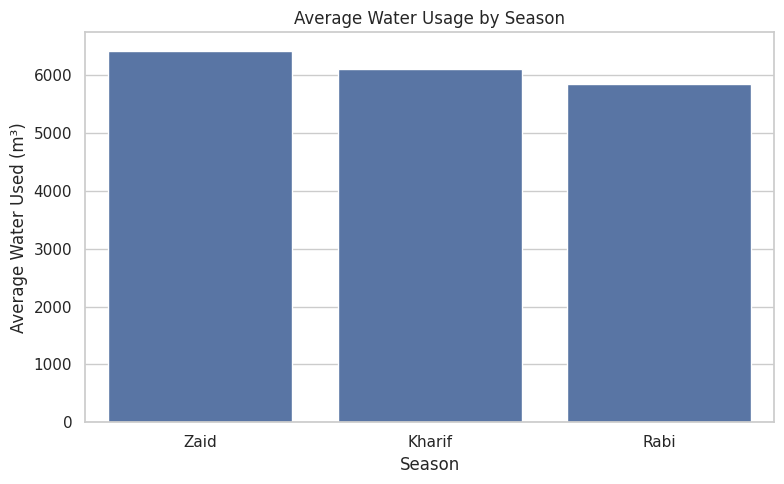

In [ ]:
# Average water usage by season

if "Water_Used_m3" in df.columns:

    water_season = (
        df.groupby("Season")["Water_Used_m3"]
        .mean()
        .sort_values(ascending=False)
    )

    print(water_season)

    plt.figure(figsize=(8, 5))

    sns.barplot(
        x=water_season.index,
        y=water_season.values
    )

    plt.title("Average Water Usage by Season")
    plt.xlabel("Season")
    plt.ylabel("Average Water Used (m³)")

    plt.tight_layout()
    plt.show()

# 9. Outlier Analysis

Outliers are observations that are unusually high or low compared with the rest of the data.

The Interquartile Range (IQR) method is used to identify potential outliers.

In [ ]:
# IQR-based outlier summary

outlier_summary = []

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Column": col,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": count,
        "Outlier_Percentage": round(
            count / len(df) * 100, 2
        )
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary = outlier_summary.sort_values(
    "Outlier_Count",
    ascending=False
)

outlier_summary

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


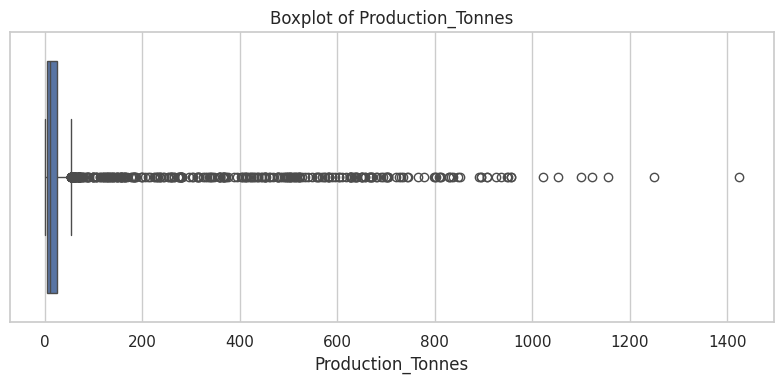

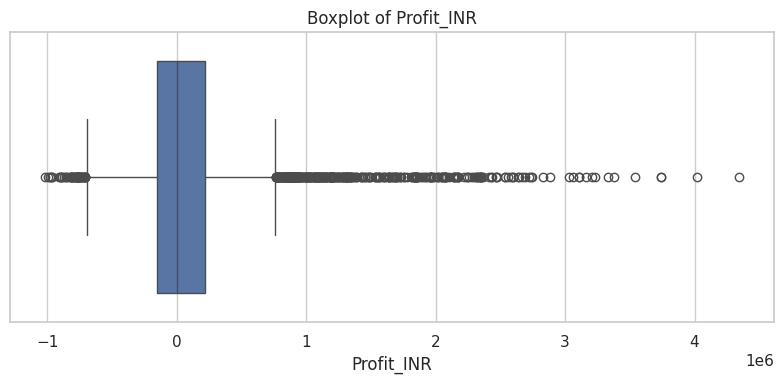

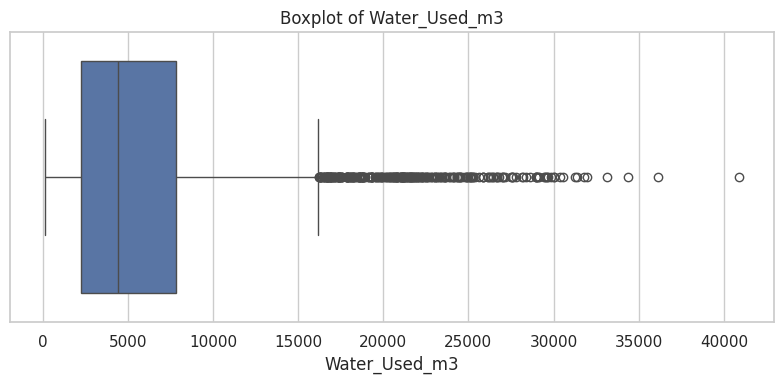

In [ ]:
# Boxplot of selected performance variables

important_variables = [
    col for col in [
        "Production_Tonnes",
        "Yield_tonnes_ha",
        "Profit_INR",
        "Water_Used_m3"
    ]
    if col in df.columns
]

for col in important_variables:

    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

# 10. Relationship Analysis

Investigate relationships between environmental conditions, resource usage and agricultural performance.

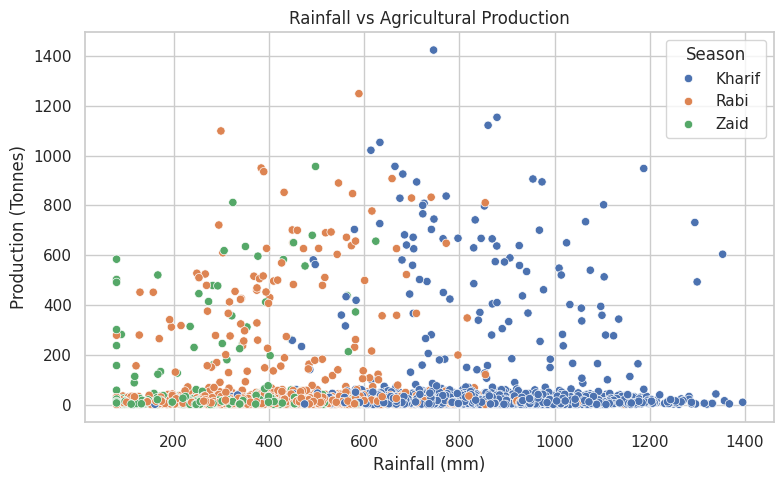

In [ ]:
# Rainfall vs Production

if "Rainfall_mm" in df.columns and "Production_Tonnes" in df.columns:

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df,
        x="Rainfall_mm",
        y="Production_Tonnes",
        hue="Season"
    )

    plt.title("Rainfall vs Agricultural Production")
    plt.xlabel("Rainfall (mm)")
    plt.ylabel("Production (Tonnes)")

    plt.tight_layout()
    plt.show()

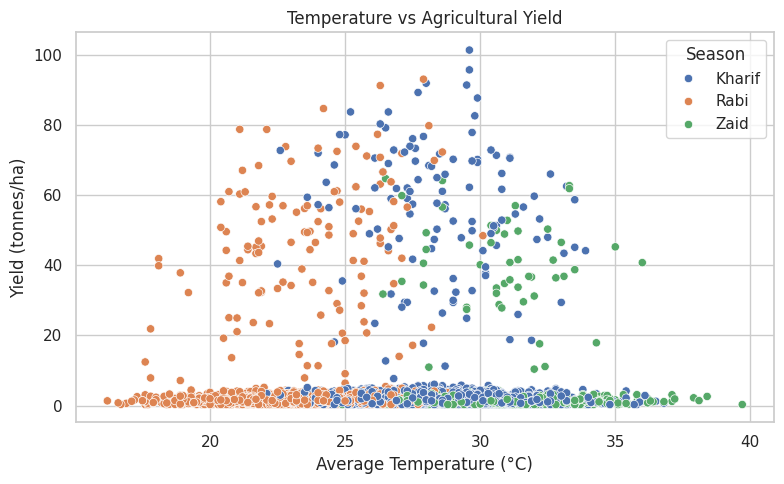

In [ ]:
# Temperature vs Yield

if "Avg_Temperature_C" in df.columns and "Yield_Tonnes_Ha" in df.columns:

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df,
        x="Avg_Temperature_C",
        y="Yield_Tonnes_Ha",
        hue="Season"
    )

    plt.title("Temperature vs Agricultural Yield")
    plt.xlabel("Average Temperature (°C)")
    plt.ylabel("Yield (tonnes/ha)")

    plt.tight_layout()
    plt.show()

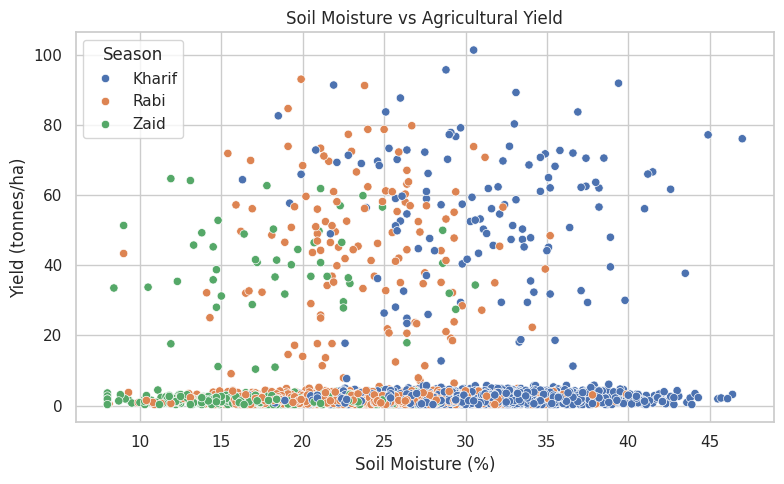

In [ ]:
# Soil Moisture vs Yield

if "Soil_Moisture_pct" in df.columns and "Yield_Tonnes_Ha" in df.columns:

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df,
        x="Soil_Moisture_pct",
        y="Yield_Tonnes_Ha",
        hue="Season"
    )

    plt.title("Soil Moisture vs Agricultural Yield")
    plt.xlabel("Soil Moisture (%)")
    plt.ylabel("Yield (tonnes/ha)")

    plt.tight_layout()
    plt.show()

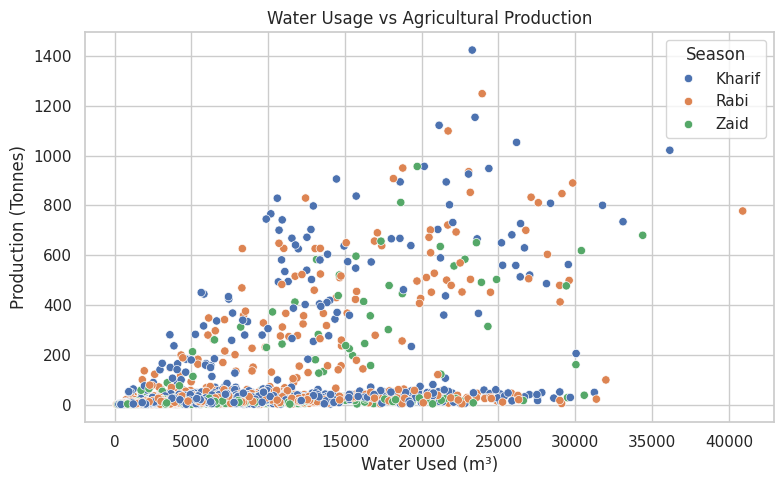

In [ ]:
# Water usage vs production

if "Water_Used_m3" in df.columns and "Production_Tonnes" in df.columns:

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df,
        x="Water_Used_m3",
        y="Production_Tonnes",
        hue="Season"
    )

    plt.title("Water Usage vs Agricultural Production")
    plt.xlabel("Water Used (m³)")
    plt.ylabel("Production (Tonnes)")

    plt.tight_layout()
    plt.show()

# 11. Correlation Analysis

Correlation analysis is used to understand the strength and direction of relationships between numerical variables.

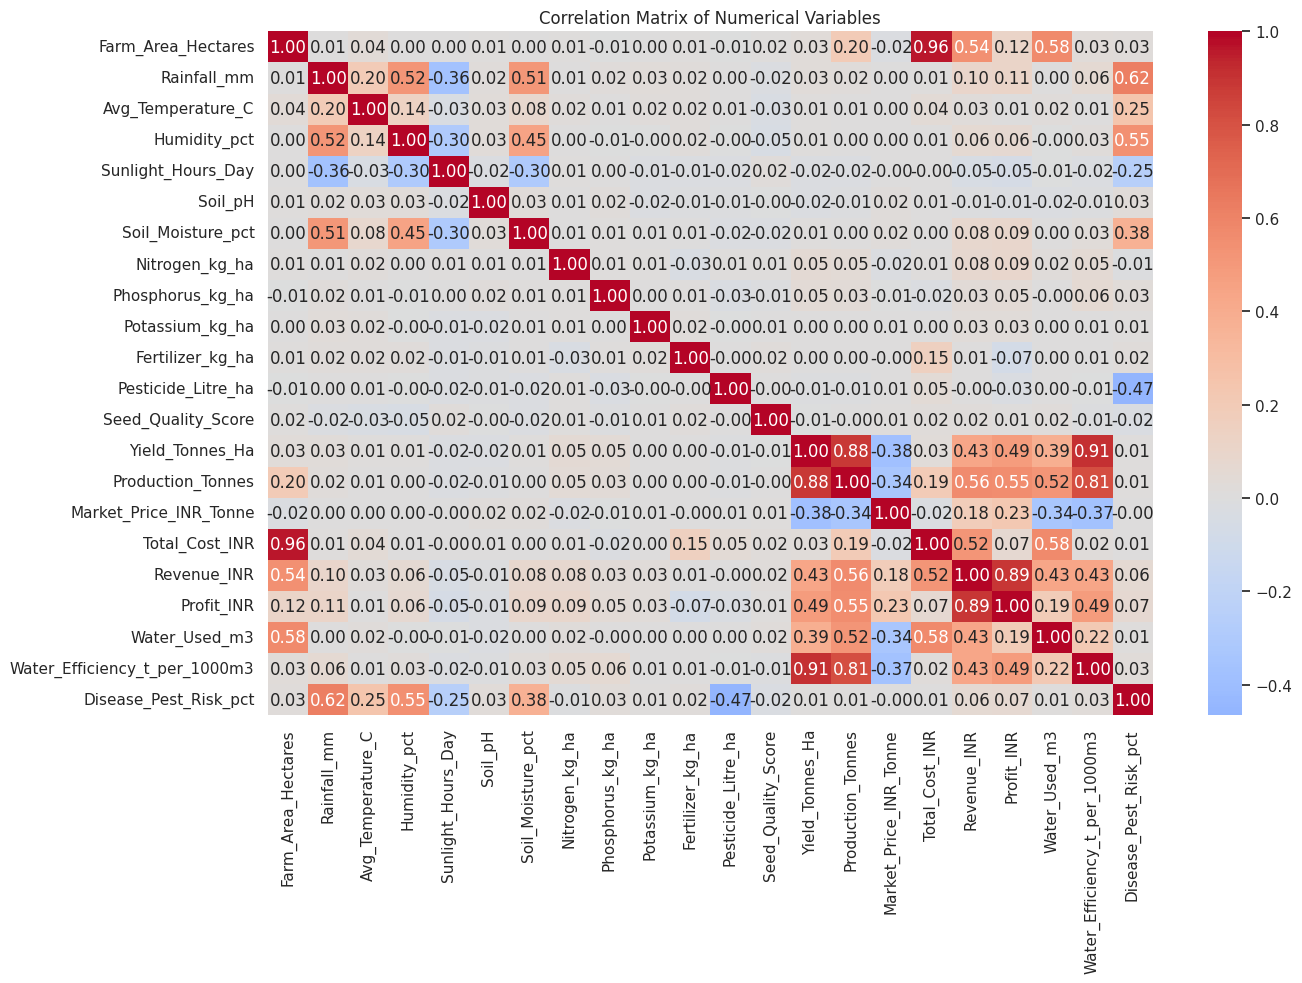

In [ ]:
# Correlation matrix

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

In [ ]:
# Variables most strongly correlated with Profit

if "Profit_INR" in df.columns:

    profit_correlation = (
        df[numeric_columns]
        .corr()["Profit_INR"]
        .sort_values(
            key=abs,
            ascending=False
        )
    )

    print(profit_correlation)

Profit_INR                       1.00
Revenue_INR                      0.89
Production_Tonnes                0.55
Water_Efficiency_t_per_1000m3    0.49
Yield_Tonnes_Ha                  0.49
Market_Price_INR_Tonne           0.23
Water_Used_m3                    0.19
Farm_Area_Hectares               0.12
Rainfall_mm                      0.11
Soil_Moisture_pct                0.09
Nitrogen_kg_ha                   0.09
Fertilizer_kg_ha                -0.07
Total_Cost_INR                   0.07
Disease_Pest_Risk_pct            0.07
Humidity_pct                     0.06
Sunlight_Hours_Day              -0.05
Phosphorus_kg_ha                 0.05
Potassium_kg_ha                  0.03
Pesticide_Litre_ha              -0.03
Soil_pH                         -0.01
Seed_Quality_Score               0.01
Avg_Temperature_C                0.01
Name: Profit_INR, dtype: float64


In [ ]:
# Variables most strongly correlated with Yield

# Select all numeric columns
numeric_columns = df.select_dtypes(include="number").columns

if "Yield_Tonnes_Ha" in df.columns:

    yield_correlation = (
        df[numeric_columns]
        .corr()["Yield_Tonnes_Ha"]
        .sort_values(
            key=abs,
            ascending=False
        )
    )

    print("Correlation of Variables with Yield:")
    print(yield_correlation)

Correlation of Variables with Yield:
Yield_Tonnes_Ha                  1.00
Water_Efficiency_t_per_1000m3    0.91
Production_Tonnes                0.88
Profit_INR                       0.49
Revenue_INR                      0.43
Water_Used_m3                    0.39
Market_Price_INR_Tonne          -0.38
Nitrogen_kg_ha                   0.05
Phosphorus_kg_ha                 0.05
Rainfall_mm                      0.03
Total_Cost_INR                   0.03
Farm_Area_Hectares               0.03
Soil_pH                         -0.02
Sunlight_Hours_Day              -0.02
Disease_Pest_Risk_pct            0.01
Humidity_pct                     0.01
Soil_Moisture_pct                0.01
Avg_Temperature_C                0.01
Pesticide_Litre_ha              -0.01
Seed_Quality_Score              -0.01
Potassium_kg_ha                  0.00
Fertilizer_kg_ha                 0.00
Name: Yield_Tonnes_Ha, dtype: float64


In [ ]:
# Seasonal performance summary

summary_columns = [
    col for col in [
        "Production_Tonnes",
        "Yield_Tonnes_Ha",
        "Profit_INR",
        "Rainfall_mm",
        "Avg_Temperature_C",
        "Humidity_pct",
        "Water_Used_m3"
    ]
    if col in df.columns
]

seasonal_summary = df.groupby("Season")[summary_columns].mean()

seasonal_summary

,Production_Tonnes,Yield_Tonnes_Ha,Profit_INR,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Water_Used_m3
Season,,,,,,,
Kharif,46.31,5.63,"178,914.65",849.20,28.45,71.81,"6,102.20"
Rabi,41.49,5.04,"87,689.47",437.62,23.49,57.89,"5,846.99"
Zaid,38.89,4.64,"-24,804.82",304.65,31.04,52.01,"6,419.89"


In [78]:
# 42. Crop-wise and season-wise average yield

crop_season_yield = (
    df.groupby(["Crop", "Season"])["Yield_Tonnes_Ha"]
      .mean()
      .unstack()
)

print("Crop-wise and Season-wise Average Yield:")
display(crop_season_yield.round(2))

Crop-wise and Season-wise Average Yield:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


In [72]:
# 43. Average production by crop

crop_production = (
    df.groupby("Crop")["Production_Tonnes"]
      .mean()
      .sort_values(ascending=False)
)

print("Average Production by Crop:")
display(crop_production.round(2))

Average Production by Crop:


,Production_Tonnes
Crop,
Sugarcane,392.41
Maize,21.78
Rice,19.29
Wheat,16.85
Chilli,12.38
Groundnut,9.66
Cotton,9.40
Pulses,7.40


In [74]:
# 44. Average profit by state

state_profit = (
    df.groupby("State")["Profit_INR"]
      .mean()
      .sort_values(ascending=False)
)

print("Average Profit by State:")
display(state_profit.round(2))

Average Profit by State:


,Profit_INR
State,
Punjab,"136,025.64"
Maharashtra,"135,428.86"
Karnataka,"119,422.34"
Tamil Nadu,"117,744.75"
Gujarat,"117,568.24"
Telangana,"108,829.62"
Madhya Pradesh,"86,840.76"
Andhra Pradesh,"73,453.53"


In [76]:
# 45. Identify the season with the highest average yield

season_yield = (
    df.groupby("Season")["Yield_Tonnes_Ha"]
      .mean()
)

best_season = season_yield.idxmax()
best_value = season_yield.max()

print("Best performing season based on average yield:", best_season)
print("Average yield:", round(best_value, 2))

Best performing season based on average yield: Kharif
Average yield: 5.63


In [77]:
# Identify the most profitable season

if "Profit_INR" in df.columns:

    profitable_season = (
        df.groupby("Season")["Profit_INR"]
        .mean()
        .idxmax()
    )

    profit_value = (
        df.groupby("Season")["Profit_INR"]
        .mean()
        .max()
    )

    print("Most profitable season:", profitable_season)
    print("Average profit:", round(profit_value, 2))

Most profitable season: Kharif
Average profit: 178914.65


# 12. Key Findings

Based on the analysis, summarize the important observations.

1. Seasonal agricultural performance varies across different seasons.
2. Production and yield should be compared across seasons to identify the best-performing periods.
3. Environmental factors such as rainfall, temperature, humidity and soil moisture may show seasonal variations.
4. Resource usage such as water usage may differ between seasons.
5. Economic performance can be compared using cost, revenue and profit.
6. Correlation analysis helps identify numerical variables associated with agricultural outcomes.
7. Outlier analysis helps identify unusually high or low agricultural observations.
8. Crop-wise and state-wise comparisons can reveal additional differences in agricultural performance.

# 13. Conclusion

The Seasonal Agriculture Performance Analysis examined agricultural records across different seasons, crops and geographical conditions.

The analysis included data understanding, data quality checking, data cleaning, seasonal analysis, distribution analysis, outlier analysis, relationship analysis and correlation analysis.

The results help identify how agricultural production, yield, resource usage and economic performance vary across seasons.

The analysis demonstrates that data analytics can be used to identify meaningful seasonal patterns and support evidence-based agricultural planning.

# 14. Recommendations

1. Agricultural planning should consider seasonal differences in environmental conditions.

2. Farmers and agricultural planners can compare production and yield across seasons to identify favorable periods.

3. Water usage should be monitored across seasons to identify opportunities for efficient resource utilization.

4. Environmental factors such as rainfall, temperature, humidity and soil moisture should be considered when evaluating agricultural performance.

5. Crop-wise and region-wise performance should be compared before making agricultural planning decisions.

6. Unusual observations identified through outlier analysis should be investigated further.

7. Historical agricultural data should continue to be collected and analyzed to support evidence-based seasonal planning.

# 15. Final Summary

The project analyzed seasonal agricultural performance using Python-based data analytics techniques.

The major stages of the project were:

- Dataset loading
- Initial data understanding
- Data quality analysis
- Missing-value analysis
- Duplicate analysis
- Data cleaning
- Variable classification
- Seasonal analysis
- Univariate analysis
- Outlier analysis
- Seasonal performance comparison
- Relationship analysis
- Correlation analysis
- Interpretation of findings
- Conclusions
- Recommendations

The analysis provides meaningful insights into seasonal variations in agricultural performance and supports data-driven agricultural planning.